In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
!pip install tensorflow

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vbookshelf/rice-leaf-diseases")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/rice-leaf-diseases


In [ ]:
base_path = "/kaggle/input/rice-leaf-diseases/rice_leaf_diseases"

In [ ]:
class_names = os.listdir(base_path)
print("Classes found:", class_names)

Classes found: ['Brown spot', 'Bacterial leaf blight', 'Leaf smut']


/tmp/ipython-input-3459530128.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="Set2")


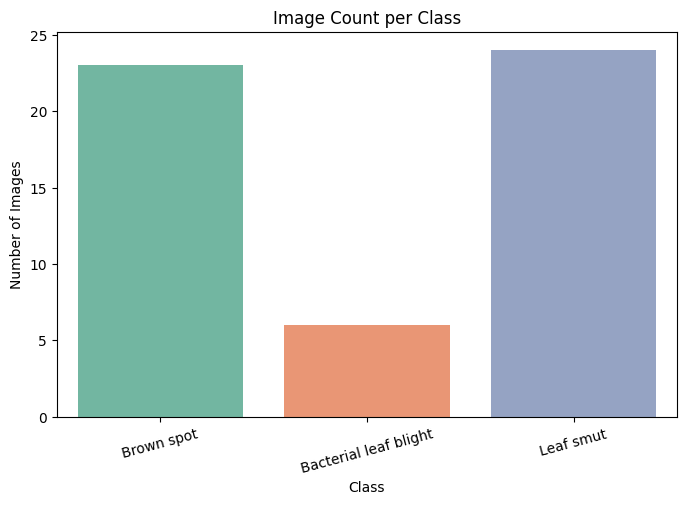

In [ ]:
image_counts = {}
image_paths = {}

for cls in class_names:
    class_dir = os.path.join(base_path, cls)
    images = glob(os.path.join(class_dir, "*.jpg"))
    image_counts[cls] = len(images)
    image_paths[cls] = images

# Display class distribution
plt.figure(figsize=(8,5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="Set2")
plt.title("Image Count per Class")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.xticks(rotation=15)
plt.show()

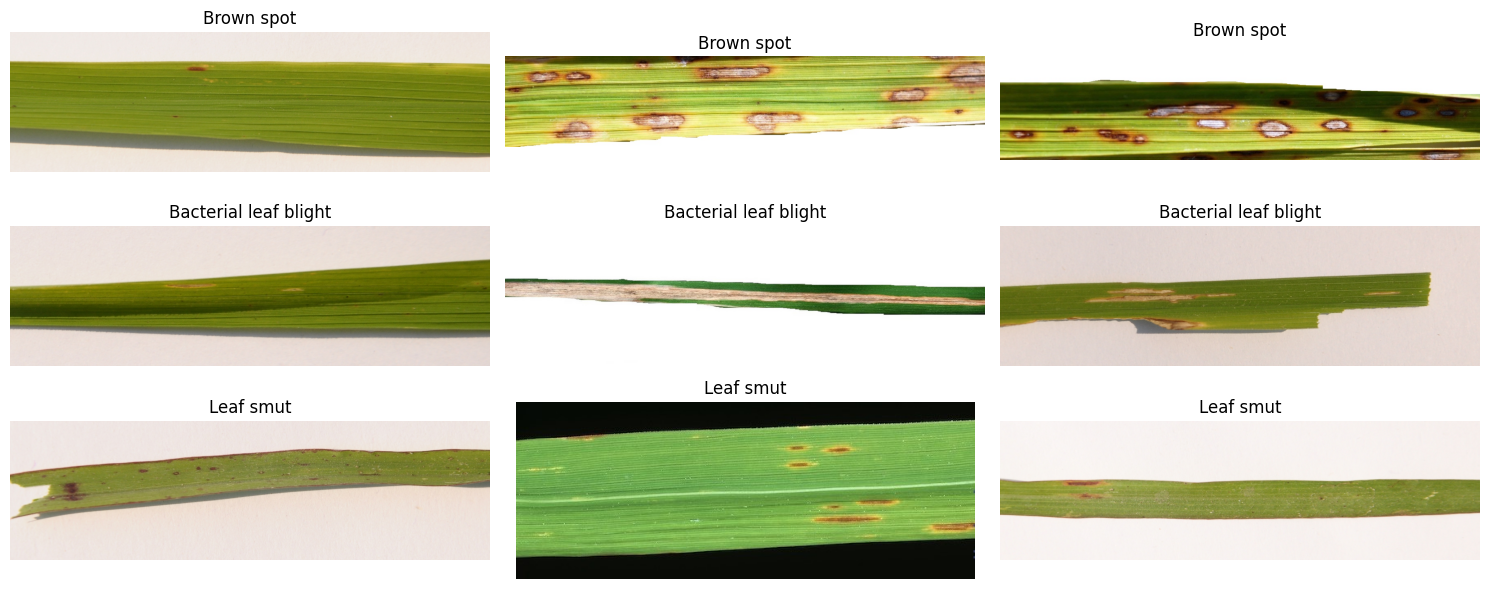

In [ ]:
def show_sample_images(image_paths, class_names, num_images=3):
    plt.figure(figsize=(15, 6))
    for idx, cls in enumerate(class_names):
        for i in range(num_images):
            img_path = image_paths[cls][i]
            img = Image.open(img_path)
            plt.subplot(len(class_names), num_images, idx*num_images + i + 1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(image_paths, class_names)

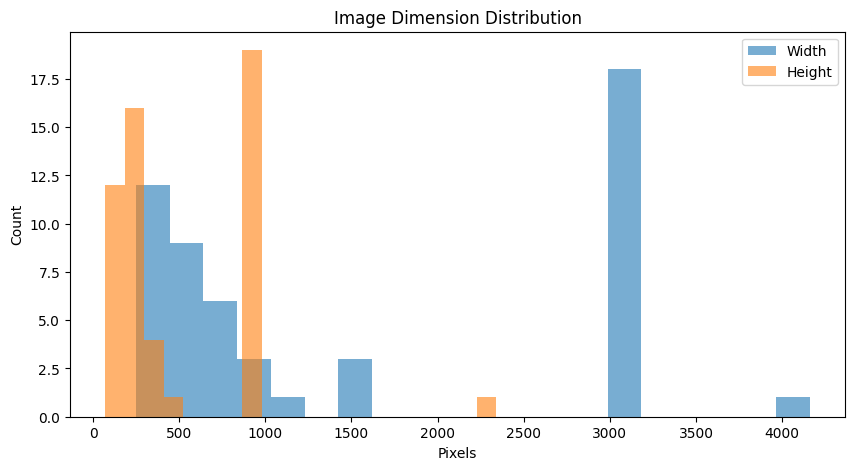

In [ ]:
image_sizes = []
for cls in class_names:
    for path in image_paths[cls][:100]:  # check only first 100 to save time
        img = Image.open(path)
        image_sizes.append(img.size)

widths, heights = zip(*image_sizes)
plt.figure(figsize=(10, 5))
plt.hist(widths, bins=20, alpha=0.6, label='Width')
plt.hist(heights, bins=20, alpha=0.6, label='Height')
plt.title("Image Dimension Distribution")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
print("Number of classes:", len(class_names))
print("Total images:", sum(image_counts.values()))
print("Sample image size (WxH):", image_sizes[0])

Number of classes: 3
Total images: 53
Sample image size (WxH): (3081, 897)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import os

In [ ]:
img_size = (128, 128)
batch_size = 32

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    base_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = datagen.flow_from_directory(
    base_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


In [ ]:
# Class indices
print("Class indices:", train_gen.class_indices)

Class indices: {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


In [ ]:

# CNN Model
from tensorflow.keras import Input

model = models.Sequential([
    Input(shape=(img_size[0], img_size[1], 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.3763 - loss: 1.3210 - val_accuracy: 0.3333 - val_loss: 1.1425
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3398 - loss: 1.1519 - val_accuracy: 0.3333 - val_loss: 1.0894
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4375 - loss: 1.0870 - val_accuracy: 0.3333 - val_loss: 1.0883
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4922 - loss: 1.0790 - val_accuracy: 0.5417 - val_loss: 1.0717
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.4076 - loss: 1.0710 - val_accuracy: 0.3750 - val_loss: 1.0647
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4531 - loss: 1.0352 - val_accuracy: 0.6250 - val_loss: 1.0065
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5469 - loss: 0.9639 - val_accuracy: 0.4167 - val_loss: 0.9912
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5846 - loss: 0.9150 - val_accuracy: 0.4167 - val_loss: 1.0652
Epoch 9/10
3/3

In [ ]:
# Evaluate model
loss, acc = model.evaluate(val_gen)
print(f"\n✅ Validation Accuracy: {acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step - accuracy: 0.4167 - loss: 1.0384

✅ Validation Accuracy: 0.42


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Input
import os

In [ ]:
# Evaluate and predict
val_gen.reset()
predictions = model.predict(val_gen, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

In [ ]:
# Plot training history
def plot_history(hist):
    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Train Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Train Loss')
    plt.plot(hist.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Plot confusion matrix
def plot_conf_matrix(cm, classes):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/kaggle/working/rice_leaf_disease_model.h5')

# Compile again (recommended if optimizer state isn't crucial)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Resume training
model.fit(train_gen, validation_data=val_gen, epochs=5)


Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5755 - loss: 0.8778 - val_accuracy: 0.5000 - val_loss: 1.3946
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6549 - loss: 0.8301 - val_accuracy: 0.5000 - val_loss: 1.1274
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6979 - loss: 0.7470 - val_accuracy: 0.5833 - val_loss: 0.7897
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8047 - loss: 0.6743 - val_accuracy: 0.5417 - val_loss: 0.7337
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7409 - loss: 0.6157 - val_accuracy: 0.5417 - val_loss: 0.7074


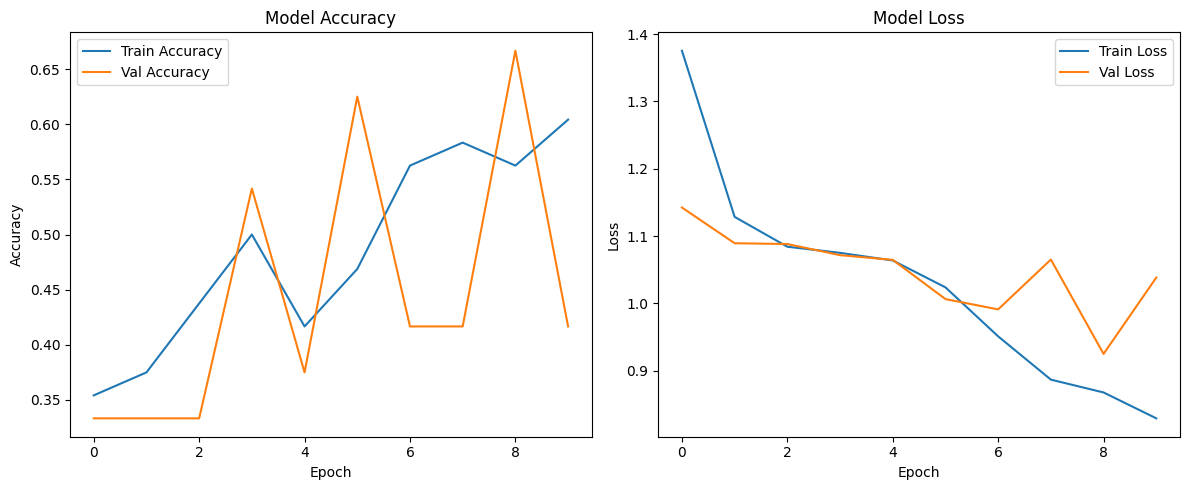

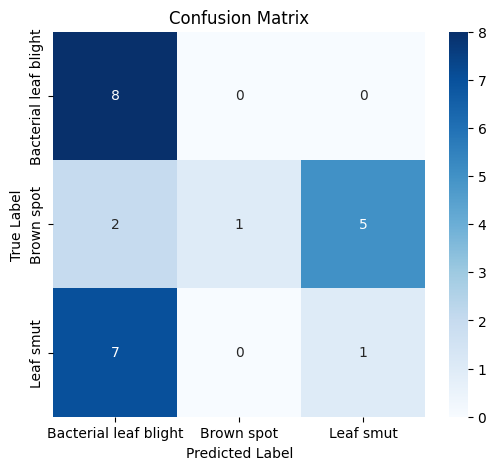

In [ ]:
# Display plots
plot_history(history)
plot_conf_matrix(cm, class_names)